In [1]:
# [설정] 작업 경로를 프로젝트 루트(ess-battery-project)로 맞춘다.
# notebooks/ 안에서 열어도 이후 모든 경로(results/, reports/ ...)가 루트 기준으로 동작한다.
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "features.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("ess-battery-project 루트를 찾지 못했습니다. 노트북을 프로젝트 안에서 여세요.")
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "src" / "eda"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

import features as Fm          # src/features.py — 피처 정의 · 사이클 창 검사
import plot_style as ps        # src/plot_style.py — 한글 폰트 · 배치 색
from data import load_all

%matplotlib inline
import matplotlib.pyplot as plt

KR = {"dQ_logvar": "ΔQ 깊이", "Qcc_init": "초기 용량", "cc_breakin": "초기 용량 상승폭", "dQ_skew": "ΔQ 왜도",
      "dQ_kurt": "ΔQ 첨도", "fade_slope_91_100": "후반 용량 기울기", "chargetime_avg5": "초기 충전시간",
      "Tavg_mean": "평균 온도", "IR_min": "내부저항 최소", "IR_diff": "내부저항 변화"}
BLUE, GRAY, INK = ps.BATCH_COLOR["batch1"], "#94A3B8", "#0B1220"
print("작업 경로: 프로젝트 루트", Path.cwd().name)

작업 경로: 프로젝트 루트 ess-battery-project


# 02. 피처 엔지니어링 — EDA 결론을 계산 가능한 피처로

**이 노트북의 목적**
- 01 EDA에서 고른 피처를 `src/features.py`로 계산하는 과정을 보여준다.
- 미래 정보가 섞이지 않도록 '사용 사이클 ≤ 100' 검사가 실제로 작동하는지 확인한다.
- Batch 1(학습)에서 피처와 수명의 관계, 피처끼리의 중복(다중공선성)을 점검한다.

**원칙**
- 피처 목록은 DAY 1에 고정했다. 이 노트북은 피처를 새로 고르지 않는다.
- 수명 라벨을 쓰는 분석은 Batch 1 라벨 36셀에서만 한다. Batch 2·3은 라벨 없이 피처 분포만 본다.
- 상관은 인과가 아니다.

## 1. 어떤 피처를 계산하는가

**질문** EDA 결론을 어떤 숫자로 바꾸는가?

| 코드 이름 | 한국어 이름 | 정의 (cycle 2\~100만 사용) | 쓰이는 모델 |
|---|---|---|---|
| dQ_logvar | ΔQ 깊이 | log10(var(Q₁₀₀(V) − Q₁₀(V))), 1,000개 전압점 | M0 · M1 · M2 · M3 · M4 |
| Qcc_init | 초기 용량 | cycle 2\~6의 CC 방전 종료 용량(2.0 V 끝점) 중앙값 | M1 · M2 · M3 · M4 |
| cc_breakin | 초기 용량 상승폭 | cycle 2\~100 끝점의 최댓값 − 초기 용량 | M2만 |
| dQ_skew · dQ_kurt | ΔQ 왜도 · 첨도 | ΔQ(V) 곡선의 모양 통계 | M2만 |
| fade_slope_91_100 | 후반 용량 기울기 | cycle 91\~100 방전 용량의 기울기 | M2만 |
| chargetime_avg5 | 초기 충전시간 | cycle 2\~6 충전시간 평균 | M2만 |
| Tavg_mean | 평균 온도 | cycle 2\~100 평균 온도의 평균 | M2만 |
| IR_min · IR_diff | 내부저항 최소 · 변화 | cycle 2\~100 최솟값, cycle 100 − cycle 2 | M2만 |

**방법**
- `src/features.py`는 셀마다 `EarlyCycles`라는 '보기(view)'를 만든다.
- 이 보기는 cycle 2\~100만 보여주고, 실제로 읽은 사이클 번호를 기록한다.
- 아래는 셀 하나(batch1-05)의 계산 결과다.

In [2]:
cells = load_all()
by_key = {c["cell_key"]: c for c in cells}
print("M0 입력:", [Fm.MAIN_FEATURE])
print("M1 입력:", Fm.M1_FEATURES)
print("M2 풀  :", Fm.M2_POOL)

example = Fm.cell_features(by_key["batch1-05"])        # 셀 하나의 피처 계산 (cycle 2~100만 사용)
pd.Series({f"{KR[k]} ({k})": example[k] for k in Fm.M2_POOL} | {"사용한 사이클 최댓값": example["max_cycle_used"]},
          name="batch1-05").to_frame()

M0 입력: ['dQ_logvar']
M1 입력: ['dQ_logvar', 'Qcc_init']
M2 풀  : ['dQ_logvar', 'Qcc_init', 'cc_breakin', 'dQ_skew', 'dQ_kurt', 'fade_slope_91_100', 'chargetime_avg5', 'Tavg_mean', 'IR_min', 'IR_diff']


,batch1-05
ΔQ 깊이 (dQ_logvar),-4.178878
초기 용량 (Qcc_init),1.061628
초기 용량 상승폭 (cc_breakin),1.974344
ΔQ 왜도 (dQ_skew),-0.149350
ΔQ 첨도 (dQ_kurt),-1.227526
후반 용량 기울기 (fade_slope_91_100),-2.322303
초기 충전시간 (chargetime_avg5),10.967850
평균 온도 (Tavg_mean),30.921498
내부저항 최소 (IR_min),0.015923
내부저항 변화 (IR_diff),-0.000112


- 셀 하나에서 피처 10개가 나온다. 마지막 줄은 계산에 쓴 가장 늦은 사이클이다.

---
## 2. 미래 정보 차단 — '사용 사이클 ≤ 100' 검사

**질문** 피처 계산이 cycle 100 이후 데이터를 몰래 쓰지는 않는가?

**방법**
- 일부러 cycle 101을 읽어 본다. `EarlyCycles`가 막아야 한다.
- 전체 139셀의 피처를 메모리에서 다시 계산한다. 저장된 `results/features.csv`, DAY 1 EDA 값과 같은지 비교한다(파일은 다시 쓰지 않는다).
- 모델 선택 단계가 읽은 피처 파일과 지금 파일이 같은지 해시로 확인한다.

In [3]:
view = Fm.EarlyCycles(by_key["batch1-05"])
try:
    view.qdlin(101)                                       # 일부러 cycle 101을 읽어 본다
except AssertionError as err:
    print("차단됨 →", err)

rebuilt = Fm.build_feature_table(cells)                    # 139셀 전체 재계산 (셀마다 사용 사이클 ≤ 100 assert)
saved = pd.read_csv("results/features.csv")
same_layout = rebuilt["cell_key"].equals(saved["cell_key"]) and \
    (rebuilt[Fm.M2_POOL].isna().to_numpy() == saved[Fm.M2_POOL].isna().to_numpy()).all()
max_diff = np.nanmax(np.abs(rebuilt[Fm.M2_POOL].to_numpy(float) - saved[Fm.M2_POOL].to_numpy(float)))
day1_diff = Fm.check_against_day1(rebuilt).max()
sha = hashlib.sha256(Path("results/features.csv").read_bytes()).hexdigest()
sel_sha = json.loads(Path("results/selection.json").read_text())["features_csv_sha256"]

pd.Series({"셀 수": len(rebuilt),
           "사용한 사이클 최댓값 (전체 셀)": int(rebuilt["max_cycle_used"].max()),
           "저장 파일과 셀 순서·결측 위치 동일": bool(same_layout),
           "저장 파일과 최대 차이": f"{max_diff:.1e}",
           "DAY 1 EDA 값과 최대 차이": f"{day1_diff:.1e}",
           "모델 선택에 쓴 파일과 해시 동일": sha == sel_sha}, name="확인 결과").to_frame()

차단됨 → batch1-05: cycle 101 은 허용 창(2~100) 밖


,확인 결과
셀 수,139
사용한 사이클 최댓값 (전체 셀),100
저장 파일과 셀 순서·결측 위치 동일,True
저장 파일과 최대 차이,3.6e-15
DAY 1 EDA 값과 최대 차이,3.6e-15
모델 선택에 쓴 파일과 해시 동일,True


**결과**
- cycle 101 접근은 오류로 막힌다.
- 139셀 모두 사용한 사이클의 최댓값이 100이다.
- 다시 계산한 값은 저장 파일, DAY 1 EDA 값과 같다. 차이는 부동소수점 반올림 수준이다.
- 모델 선택(03 노트북)은 바로 이 파일로 진행됐다.

**해석·시사점**
- knee처럼 수명 뒤쪽에서만 알 수 있는 정보는 구조적으로 피처에 들어갈 수 없다.
- EDA → 피처 → 모델이 같은 정의, 같은 파일로 이어진다(재현 가능한 파이프라인).

---
## 3. 피처와 수명의 관계 (Batch 1)

**질문**
- 각 피처는 log10 수명과 얼마나 함께 움직이는가?
- ΔQ 깊이를 빼고도 남는 정보가 있는가?

**방법**
- Batch 1 라벨 36셀에서 각 피처와 log10(cycle_life)의 Spearman 순위상관(ρ)을 구한다.
- **편상관**: ΔQ 깊이로 설명되는 부분을 피처와 수명 양쪽에서 빼고, 남은 부분끼리의 상관을 본다. ΔQ 깊이에 '더해서' 주는 정보를 잰다.

,이름,Spearman ρ,ΔQ 깊이 통제 편상관
피처,,,
dQ_logvar,ΔQ 깊이,-0.83,NaN
Qcc_init,초기 용량,0.15,0.68
cc_breakin,초기 용량 상승폭,0.30,-0.62
dQ_skew,ΔQ 왜도,-0.42,0.30
dQ_kurt,ΔQ 첨도,0.24,-0.05
fade_slope_91_100,후반 용량 기울기,0.32,0.05
chargetime_avg5,초기 충전시간,0.43,0.12
Tavg_mean,평균 온도,-0.12,-0.07
IR_min,내부저항 최소,0.24,0.12


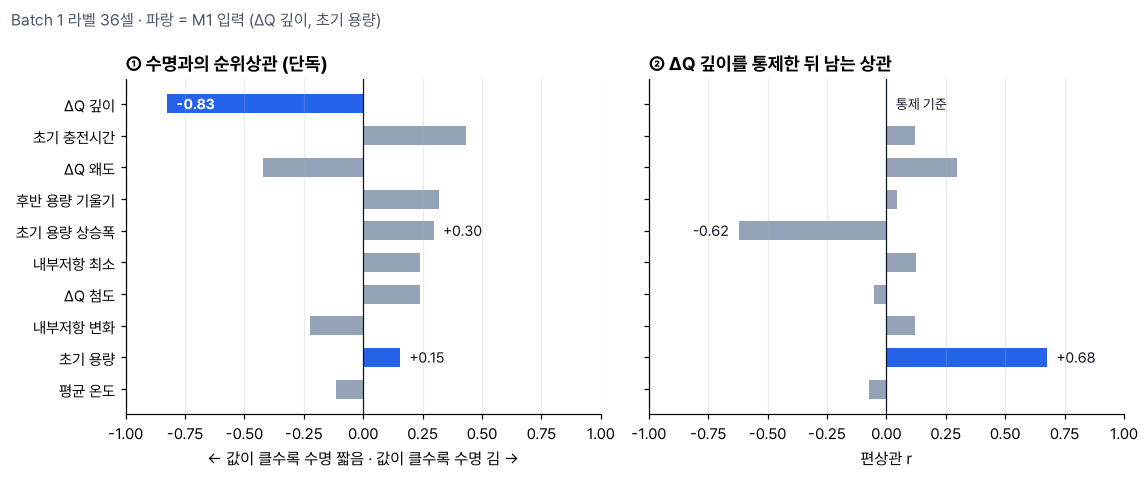

In [4]:
B1 = saved[(saved["batch"] == "batch1") & saved["labeled"]].copy()       # Batch 1 라벨 36셀만
y = np.log10(B1["cycle_life"]).to_numpy()
depth = B1["dQ_logvar"].to_numpy()


def residual(v, ctrl):
    """ctrl(ΔQ 깊이)로 설명되는 부분을 뺀 나머지 (절편 포함 최소제곱)."""
    A = np.column_stack([np.ones_like(ctrl), ctrl])
    return v - A @ np.linalg.lstsq(A, v, rcond=None)[0]


rows = []
for f in Fm.M2_POOL:
    x = B1[f].to_numpy(float)
    rows.append({"피처": f, "이름": KR[f], "Spearman ρ": stats.spearmanr(x, y)[0],
                 "ΔQ 깊이 통제 편상관": np.nan if f == "dQ_logvar" else
                 stats.pearsonr(residual(x, depth), residual(y, depth))[0]})
corr = pd.DataFrame(rows).set_index("피처")
display(corr.round(2))

order = corr["Spearman ρ"].abs().sort_values().index               # 아래 → 위 = 약 → 강
label_these = ["dQ_logvar", "Qcc_init", "cc_breakin"]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), sharey=True)
for ax, col, title in zip(axes, ["Spearman ρ", "ΔQ 깊이 통제 편상관"],
                          ["① 수명과의 순위상관 (단독)", "② ΔQ 깊이를 통제한 뒤 남는 상관"]):
    vals = corr.loc[order, col]
    ax.barh([KR[f] for f in order], vals.fillna(0), height=0.6,
            color=[BLUE if f in Fm.M1_FEATURES else GRAY for f in order])
    ax.axvline(0, color=INK, lw=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(title, loc="left")
    ax.grid(axis="y", visible=False)
    for i, f in enumerate(order):
        v = vals[f]
        if f not in label_these:
            continue
        if np.isnan(v):
            ax.text(0.04, i, "통제 기준", va="center", fontsize=9, color=INK)
        elif abs(v) > 0.7:                                          # 긴 막대는 막대 안쪽 끝에 흰 글씨
            ax.text(v + (-0.04 if v >= 0 else 0.04), i, f"{v:+.2f}", va="center",
                    ha="right" if v >= 0 else "left", fontsize=9.5, color="white", fontweight="bold")
        else:
            ax.text(v + (0.04 if v >= 0 else -0.04), i, f"{v:+.2f}", va="center",
                    ha="left" if v >= 0 else "right", fontsize=9.5, color=INK)
axes[0].set_xlabel("← 값이 클수록 수명 짧음 · 값이 클수록 수명 김 →")
axes[1].set_xlabel("편상관 r")
fig.suptitle("Batch 1 라벨 36셀 · 파랑 = M1 입력 (ΔQ 깊이, 초기 용량)", x=0.01, ha="left", fontsize=10.5, color="#475569")
fig.tight_layout()
plt.show()

**결과**
- ΔQ 깊이가 가장 강하다. 깊을수록 수명이 짧다.
- 다른 피처들은 단독 상관이 중간 정도지만, ΔQ 깊이를 통제하면 대부분 0 근처로 줄어든다.
- 통제 후에도 크게 남는 것은 두 개다: 초기 용량(+)과 초기 용량 상승폭(−).

**해석·시사점**
- 대부분의 피처는 ΔQ 깊이가 이미 가진 정보를 다른 방식으로 다시 재고 있다.
- 초기 용량은 혼자서는 약하지만, ΔQ 깊이와 함께 쓰면 보완 정보를 준다. 그래서 M1의 두 번째 입력이 된다.
- 초기 용량 상승폭은 단독일 때 (+)였다가 통제 후 (−)로 부호가 바뀐다. 해석이 불안정해 M2 풀 안에서만 쓴다.
- 모두 Batch 1 36셀의 상관이다. 원인이라는 뜻은 아니다.

---
## 4. 두 피처를 그림으로 — ΔQ 깊이와 초기 용량

**질문** M1의 두 입력은 수명과 각각 어떤 모양으로 관련되는가?

**방법**
- 왼쪽: ΔQ 깊이 vs 수명(로그 축). 직선이면 log10 타깃 + 선형 모델이 맞다.
- 오른쪽: ΔQ 깊이로 설명되는 부분을 뺀 뒤의 초기 용량 vs 수명. 위 편상관을 눈으로 본 것이다.

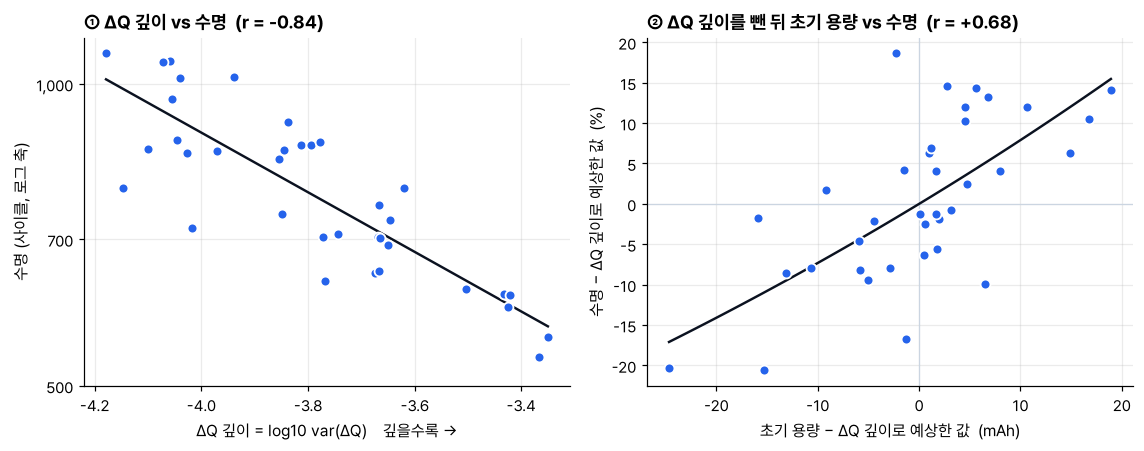

ΔQ 깊이 +1 (ΔQ 분산 10배) → 수명 ×0.50  (ΔQ 깊이만 쓴 직선)
초기 용량 +10 mAh → 수명 ×1.08  (ΔQ 깊이를 통제한 기울기)


In [5]:
fit = np.polyfit(depth, y, 1)
rq, ry = residual(B1["Qcc_init"].to_numpy(float), depth), residual(y, depth)
k = np.polyfit(rq, ry, 1)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax = axes[0]
xs = np.linspace(depth.min(), depth.max(), 50)
ax.plot(xs, 10 ** np.polyval(fit, xs), color=INK, lw=1.6)
ax.scatter(depth, B1["cycle_life"], s=42, color=BLUE, edgecolor="white", linewidth=1.2, zorder=3)
ax.set_yscale("log")
ax.set_yticks([500, 700, 1000], ["500", "700", "1,000"])
ax.minorticks_off()
ax.set_xlabel("ΔQ 깊이 = log10 var(ΔQ)    깊을수록 →")
ax.set_ylabel("수명 (사이클, 로그 축)")
ax.set_title(f"① ΔQ 깊이 vs 수명  (r = {stats.pearsonr(depth, y)[0]:.2f})", loc="left")

ax = axes[1]
xs = np.linspace(rq.min(), rq.max(), 50)
ax.axhline(0, color="#CBD5E1", lw=0.8)
ax.axvline(0, color="#CBD5E1", lw=0.8)
ax.plot(xs * 1000, (10 ** np.polyval(k, xs) - 1) * 100, color=INK, lw=1.6)
ax.scatter(rq * 1000, (10 ** ry - 1) * 100, s=42, color=BLUE, edgecolor="white", linewidth=1.2, zorder=3)
ax.set_xlabel("초기 용량 − ΔQ 깊이로 예상한 값  (mAh)")
ax.set_ylabel("수명 − ΔQ 깊이로 예상한 값  (%)")
ax.set_title(f"② ΔQ 깊이를 뺀 뒤 초기 용량 vs 수명  (r = {stats.pearsonr(rq, ry)[0]:+.2f})", loc="left")
fig.tight_layout()
plt.show()

print(f"ΔQ 깊이 +1 (ΔQ 분산 10배) → 수명 ×{10 ** fit[0]:.2f}  (ΔQ 깊이만 쓴 직선)")
print(f"초기 용량 +10 mAh → 수명 ×{10 ** (k[0] * 0.010):.2f}  (ΔQ 깊이를 통제한 기울기)")

**결과**
- 왼쪽: 점들이 로그 축 위에서 거의 직선에 놓인다.
- ΔQ 분산이 10배 커지면 수명은 약 절반으로 줄어든다.
- 오른쪽: ΔQ 깊이로 설명하고 남은 부분에서, 초기 용량이 큰 셀이 수명도 길다.
- 초기 용량 10 mAh 차이는 수명 약 8% 차이와 함께 간다.

**해석·시사점**
- 두 관계 모두 로그 척도에서 직선이다 → M1을 **log10 타깃 + 선형(Ridge)** 으로 만든 근거다.
- 초기 용량 효과의 일부는 라벨 정의에서 온다. EOL이 0.88 Ah로 고정이라, 처음 용량이 큰 셀은 EOL까지 '여유'가 더 있다.
  - → 이 계수를 '셀이 더 건강하다'로 읽지 않는다.
- 초기 용량은 절대 수준이라 배치가 바뀌면 기준선이 움직인다(노션 Qdlin 경고). 6절에서 라벨 없이 점검한다.

---
## 5. 다중공선성 — 피처끼리 같은 정보를 담고 있는가?

**질문** 피처끼리 너무 비슷하면 선형 모델의 계수가 불안정해진다. 우리 피처 세트는 괜찮은가?

**방법**
- Batch 1 36셀에서 M2 풀 10개의 순위상관 행렬을 그린다.
- 피처마다 VIF(분산팽창계수)를 구한다. 보통 10을 넘으면 심한 중복으로 본다.
- 비교: DAY 1에서 뺀 'ΔQ 최저점(log|min ΔQ|)'을 다시 계산해, ΔQ 깊이와 얼마나 겹치는지 본다.

,VIF (M2 풀 10개),VIF (M1 2개)
ΔQ 깊이,4.40,1.06
초기 용량,3.33,1.06
초기 용량 상승폭,4.92,—
ΔQ 왜도,3.36,—
ΔQ 첨도,2.50,—
후반 용량 기울기,3.75,—
초기 충전시간,3.79,—
평균 온도,1.53,—
내부저항 최소,3.17,—
내부저항 변화,1.86,—


(DAY 1에서 제외한 피처) ΔQ 최저점 log|min ΔQ| vs ΔQ 깊이: r = 0.996


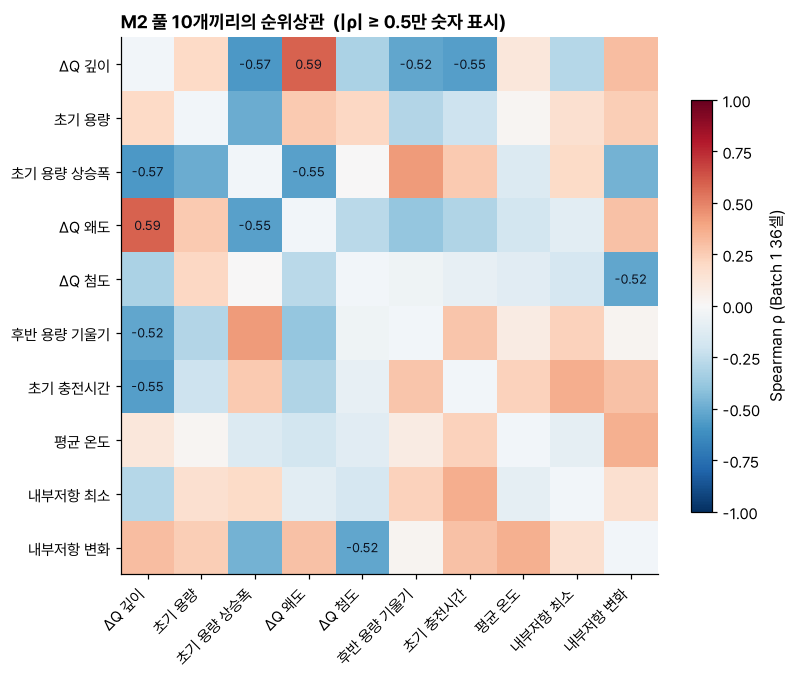

In [6]:
def vif_table(cols):
    Xc = add_constant(B1[cols])
    return pd.Series({KR[c]: variance_inflation_factor(Xc.to_numpy(float), i)
                      for i, c in enumerate(Xc.columns) if c != "const"})


vif = pd.DataFrame({"VIF (M2 풀 10개)": vif_table(Fm.M2_POOL), "VIF (M1 2개)": vif_table(Fm.M1_FEATURES)})
display(vif.reindex([KR[f] for f in Fm.M2_POOL]).round(2).fillna("—"))

absmin = [np.log10(abs(Fm.delta_q_100_10(Fm.EarlyCycles(by_key[c])).min())) for c in B1["cell_key"]]
print(f"(DAY 1에서 제외한 피처) ΔQ 최저점 log|min ΔQ| vs ΔQ 깊이: r = {stats.pearsonr(absmin, depth)[0]:.3f}")

rho_mat = B1[Fm.M2_POOL].rename(columns=KR).corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.4, 6.2))
cmap = plt.get_cmap("RdBu_r").with_extremes(bad="#F1F5F9")             # 대각선(자기 자신)은 회색으로 비움
im = ax.imshow(np.where(np.eye(len(rho_mat), dtype=bool), np.nan, rho_mat), cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(rho_mat)), rho_mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(rho_mat)), rho_mat.index)
for i in range(len(rho_mat)):
    for j in range(len(rho_mat)):
        v = rho_mat.iat[i, j]
        if i != j and abs(v) >= 0.5:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                    color="white" if abs(v) >= 0.75 else INK)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.75, label="Spearman ρ (Batch 1 36셀)")
ax.set_title("M2 풀 10개끼리의 순위상관  (|ρ| ≥ 0.5만 숫자 표시)", loc="left")
fig.tight_layout()
plt.show()

**결과**
- M2 풀 10개의 VIF는 모두 5 미만이다.
- M1의 두 피처(ΔQ 깊이·초기 용량)는 VIF가 1에 가깝다. 서로 거의 독립이다.
- 피처끼리의 순위상관은 가장 큰 쌍도 0.6 수준이다(히트맵).
- 반면 DAY 1에서 뺀 ΔQ 최저점은 ΔQ 깊이와 상관이 0.99를 넘는다. 함께 넣었다면 계수가 크게 흔들렸을 것이다.

**해석·시사점**
- DAY 1에서 '같은 정보 그룹당 하나만 남기기'를 한 덕분에 중복 문제는 관리 가능한 수준이다.
- 그래도 36셀에 피처 10개는 많다 → M2는 Elastic Net으로 계수를 줄이고, 채택 여부는 교차검증으로 정한다.
- M1은 두 피처가 독립에 가까워 계수 해석이 쉽다. ESS 현장에 설명하기에도 유리하다.

<details><summary>원논문 피처 조합을 그대로 썼다면 (DAY 1 Q5, 펼치기)</summary>

- 원논문 'full' 조합은 VIF 최대 약 618이다.
- DAY 1 주요 후보 17개를 모두 넣으면 VIF 최대 14,628이다(19개 전부면 29,545).
- 용량 수준·충전 조건·ΔQ 진폭 그룹은 정의상 같은 양을 재고 있었다(Pearson |r| 0.98\~1.00).
</details>

---
## 6. 테스트 배치에 적용할 때의 위험 — 라벨 없이 피처 분포만 비교

**질문**
- Batch 2·3 셀의 피처 값은 Batch 1 학습 범위 안에 있는가?
- 초기 용량의 기준선은 배치끼리 같은가?

**방법**
- 수명 라벨은 보지 않는다. 각 배치·그룹 **전체 셀**의 피처 값만 비교한다.
- ΔQ 깊이: Batch 1 라벨 36셀의 범위 밖에 있는 셀의 비율(범위 밖 = 외삽).
- 초기 용량: 중앙값이 Batch 1 전체 46셀 중앙값에서 얼마나 이동했는지.

,셀 수 (전체),ΔQ 깊이: 더 깊은 쪽 범위 밖,ΔQ 깊이: 더 얕은 쪽 범위 밖,초기 용량 이동 (mAh)
그룹,,,,
Batch 1 (학습),46,0,5,0.0
Batch 2 fastcharge,30,11,0,-5.3
Batch 2 newstructure,9,0,6,-8.7
Batch 3 newstructure,46,0,23,-14.5


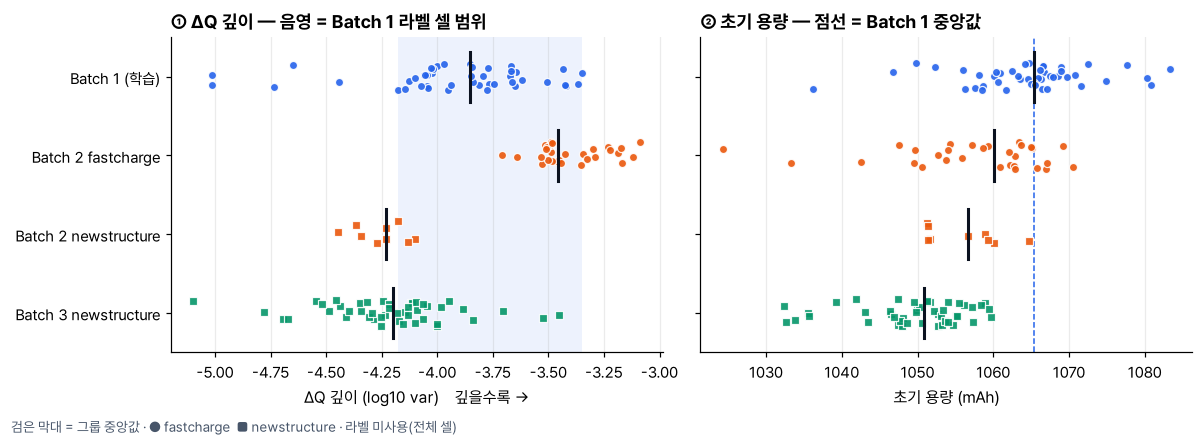

In [7]:
lo, hi = B1["dQ_logvar"].min(), B1["dQ_logvar"].max()
b1_qcc = saved.loc[saved["batch"] == "batch1", "Qcc_init"].median()
groups = [("batch1", "fastcharge", "Batch 1 (학습)"), ("batch2", "fastcharge", "Batch 2 fastcharge"),
          ("batch2", "newstructure", "Batch 2 newstructure"), ("batch3", "newstructure", "Batch 3 newstructure")]

rows = []
for b, g, label in groups:
    d = saved[(saved["batch"] == b) & (saved["group"] == g)]
    rows.append({"그룹": label, "셀 수 (전체)": len(d),
                 "ΔQ 깊이: 더 깊은 쪽 범위 밖": int((d["dQ_logvar"] > hi).sum()),
                 "ΔQ 깊이: 더 얕은 쪽 범위 밖": int((d["dQ_logvar"] < lo).sum()),
                 "초기 용량 이동 (mAh)": 1000 * (d["Qcc_init"].median() - b1_qcc)})
display(pd.DataFrame(rows).set_index("그룹").round(1))

rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
for ax, col, scale in [(axes[0], "dQ_logvar", 1), (axes[1], "Qcc_init", 1000)]:
    for i, (b, g, label) in enumerate(groups):
        d = saved[(saved["batch"] == b) & (saved["group"] == g)][col].dropna() * scale
        ax.scatter(d, i + rng.uniform(-0.18, 0.18, len(d)), s=28, color=ps.BATCH_COLOR[b], alpha=0.9,
                   edgecolor="white", linewidth=0.8, marker="o" if g == "fastcharge" else "s", zorder=3)
        ax.plot([d.median()] * 2, [i - 0.32, i + 0.32], color=INK, lw=2, zorder=4)
    ax.grid(axis="y", visible=False)
axes[0].axvspan(lo, hi, color=BLUE, alpha=0.08, lw=0)
axes[1].axvline(b1_qcc * 1000, color=BLUE, ls="--", lw=1)
axes[0].set_yticks(range(len(groups)), [g[2] for g in groups])
axes[0].invert_yaxis()
axes[0].set_xlabel("ΔQ 깊이 (log10 var)    깊을수록 →")
axes[1].set_xlabel("초기 용량 (mAh)")
axes[0].set_title("① ΔQ 깊이 — 음영 = Batch 1 라벨 셀 범위", loc="left")
axes[1].set_title("② 초기 용량 — 점선 = Batch 1 중앙값", loc="left")
fig.text(0.01, -0.02, "검은 막대 = 그룹 중앙값 · ● fastcharge  ■ newstructure · 라벨 미사용(전체 셀)", fontsize=9, color="#475569")
fig.tight_layout()
plt.show()

**결과**
- Batch 2 newstructure와 Batch 3는 ΔQ 깊이가 **얕은 쪽**으로 학습 범위를 많이 벗어난다. 학습 셀보다 오래 살 것 같은 셀이다.
- Batch 2 fastcharge는 약 1/3이 **깊은 쪽**으로 범위를 벗어난다. 학습 셀보다 짧게 살 것 같은 셀이다.
- 초기 용량은 세 테스트 그룹 모두 Batch 1보다 낮다. Batch 3에서 가장 크게 내려갔다.
- Batch 1의 범위 밖 셀은 중도절단 셀이다. 03 노트북의 외삽 게이트에 쓰인다.

**해석·시사점**
- 선형 모델을 택한 근거는 Batch 1이다. Batch 1 중도절단 장수명 5셀(#00\~04)도 이미 범위 밖이라, 범위 밖에서도 직선이 이어지는 모델이 필요했다(01 노트북 Q1).
- 테스트 셀의 상당수가 '본 적 없는 값'에서 예측된다는 점은 위험으로 기록했다(설계 근거 아님).
- 초기 용량 이동은 라벨 없이도 보이는 배치 차이다(01 노트북 추가 확인과 같은 값).
- 테스트 배치 통계로 피처를 다시 맞추지 않았다(테스트 정보 누수). 대신 이 위험을 테스트 전에 기록하고, 03 노트북에서 실제 오차와 비교한다.

---
## 정리

- 모델 입력은 DAY 1 계획 그대로다: **M0** = ΔQ 깊이, **M1** = ΔQ 깊이 + 초기 용량, **M2** = 10개 풀.
- 피처는 cycle 100 이후 정보를 쓰지 않는다. 코드가 강제한다.
- 테스트 전에 두 가지 위험을 기록했다.
  1. 테스트 셀의 상당수가 ΔQ 깊이 학습 범위 밖에 있다.
  2. 초기 용량의 기준선이 배치마다 이동한다.
- 03 노트북에서 이 위험이 실제 오차에 어떻게 나타났는지 본다.